In [1]:
SEED = 42

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

In [4]:
def header(title, width=80):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def subheader(title, width=80):
    print("\n" + "-" * width)
    print(title.center(width))
    print("-" * width)

def kv(key, value, width=30):
    print(f"{key:<{width}} : {value}")

In [5]:
train_filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]

test_filenames = [
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
]

subheader("Загружаем тренировочные ИИ-тексты")
train_ai_datasets = pd.DataFrame(columns=["text", "label"])
for fn in train_filenames:
    df = pd.read_csv(fn, encoding="utf-8").drop_duplicates().assign(label=1)[["text", "label"]].reset_index(drop=True)
    train_ai_datasets = pd.concat(
        [train_ai_datasets, df],
        ignore_index=True
    )
    
    print(f"Загружен датасет '{fn}'. {len(df)} записей")
train_ai_datasets = train_ai_datasets.drop_duplicates()

subheader("Загружаем тестовые ИИ-тексты")
test_ai_datasets = pd.DataFrame(columns=["text", "label"])
for fn in test_filenames:
    df = pd.read_csv(fn, encoding="utf-8").drop_duplicates().assign(label=1)[["text", "label"]].reset_index(drop=True)
    test_ai_datasets = pd.concat(
        [test_ai_datasets, df],
        ignore_index=True
    )
    
    print(f"Загружен датасет '{fn}'. {len(df)} записей")
test_ai_datasets = test_ai_datasets.drop_duplicates()

subheader("Загружаем живые тексты")
ivy_panda_df = (
    pd.read_csv("../datasets/ivy_panda_essays.csv", encoding="utf-8").drop_duplicates()
    .assign(label=0)[["text", "label"]]
    .sample(n=3 * len(test_ai_datasets), random_state=SEED)
    .reset_index(drop=True)
)
print(f"Загружен датасет 'ivy_panda_essays'. {len(ivy_panda_df)} записей")


--------------------------------------------------------------------------------
                       Загружаем тренировочные ИИ-тексты                        
--------------------------------------------------------------------------------
Загружен датасет '../datasets/mistral_essays_1.csv'. 1000 записей
Загружен датасет '../datasets/mistral_essays_2.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_3.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_4.csv'. 1500 записей
Загружен датасет '../datasets/mistral_essays_5.csv'. 1500 записей
Загружен датасет '../datasets/chatgpt_essays_1.csv'. 2000 записей
Загружен датасет '../datasets/chatgpt_essays_2.csv'. 2000 записей
Загружен датасет '../datasets/chatgpt_essays_3.csv'. 2000 записей
Загружен датасет '../datasets/chatgpt_essays_4.csv'. 2000 записей
Загружен датасет '../datasets/chatgpt_essays_5.csv'. 2000 записей

--------------------------------------------------------------------------------
              

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(ivy_panda_df['text'].tolist(), show_progress_bar=True)

num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=SEED)
cluster_labels = kmeans.fit_predict(embeddings)
ivy_panda_df['cluster'] = cluster_labels

test_fraction = 0.3
cluster_sizes = ivy_panda_df['cluster'].value_counts().sort_index()
clusters_sorted = cluster_sizes.index.tolist()[::-1]

cum_fraction = 0
test_clusters = []

for cluster in clusters_sorted:
    cum_fraction += cluster_sizes[cluster] / len(ivy_panda_df)
    if cum_fraction >= test_fraction:
        break
    test_clusters.append(cluster)

train_df = ivy_panda_df[~ivy_panda_df['cluster'].isin(test_clusters)].reset_index(drop=True)
train_df = (
    pd.concat([train_df, train_ai_datasets], ignore_index=True)
    .sample(frac=1, random_state=SEED)
)

test_df = ivy_panda_df[ivy_panda_df['cluster'].isin(test_clusters)].reset_index(drop=True)
test_df = (
    pd.concat([test_df, test_ai_datasets], ignore_index=True)
    .sample(frac=1, random_state=SEED)
)

X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(int)
X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(int)

subheader("DATA SPLIT")
kv("Total samples", len(y_train) + len(y_test))
kv("Train", f"{len(y_train)}\t({len(y_train)/(len(y_train) + len(y_test)):.0%})\t - {sum(y_train)} синтетических")
kv("Test", f"{len(y_test)}\t({len(y_test)/(len(y_train) + len(y_test)):.0%})\t - {sum(y_test)} синтетических")
kv("Test clusters", f"{test_clusters}")

Batches:   0%|          | 0/1874 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
                                   DATA SPLIT                                   
--------------------------------------------------------------------------------
Total samples                  : 96952
Train                          : 60697	(63%)	 - 17000 синтетических
Test                           : 36255	(37%)	 - 19988 синтетических
Test clusters                  : [9, 8, 7]


In [7]:
def calculate(X_train, y_train, X_test, y_test):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("clf", LogisticRegression(random_state=SEED, solver="saga", max_iter=5000)),
    ])
    
    param_grid = {
        "tfidf__max_features": [25000, 35000],
        "clf__C": [1, 10],
        "clf__l1_ratio": [0, 1]  # 0=L2, 1=L1
    }
    
    subheader("HYPERPARAMETER TUNING")
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_macro",
        verbose=0,
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    kv("GridSearch time (s)", f"{elapsed:.2f}")
    kv("Best CV accuracy", f"{grid_search.best_score_:.4f}")
    kv("Best parameters", grid_search.best_params_)
    
    subheader("CROSS-VALIDATION RESULTS (TOP 5)")
    results_df = (
        pd.DataFrame(grid_search.cv_results_)
        .assign(
            max_features=lambda d: d["param_tfidf__max_features"],
            C=lambda d: d["param_clf__C"],
            l1_ratio=lambda d: d["param_clf__l1_ratio"],
            CV_Accuracy=lambda d: d["mean_test_score"]
        )
        .sort_values("CV_Accuracy", ascending=False)
        [["max_features", "C", "l1_ratio", "CV_Accuracy"]]
        .head(5)
    )
    
    print(results_df.to_string(index=False, float_format="%.4f"))
    
    best_model = grid_search.best_estimator_
    
    vectorizer = best_model.named_steps['tfidf']
    clf = best_model.named_steps['clf']
    
    feature_names = vectorizer.get_feature_names_out()
    coef = clf.coef_[0]
    
    top_words = feature_names[np.argsort(coef)[-25:]]
    print("\nТоп слов для СГЕНЕРИРОВАННЫХ текстов:")
    print(*top_words)
    
    bottom_words = feature_names[np.argsort(coef)[:25]]
    print("\nТоп слов для ЖИВЫХ текстов:")
    print(*bottom_words)
    
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    
    subheader("ЛУЧШАЯ МОДЕЛЬ")
    kv("Train accuracy", f"{train_acc:.4f}")
    kv("Test accuracy", f"{test_acc:.4f}")

    y_test_proba = best_model.predict_proba(X_test)[:, 1]  # вероятность класса 1

    auprc = average_precision_score(y_test, y_test_proba)
    auroc = roc_auc_score(y_test, y_test_proba)
    
    kv("AUPRC (Test)", f"{auprc:.4f}")
    kv("AUROC (Test)", f"{auroc:.4f}")
    
    subheader("ИТОГО (TEST)")
    y_test_pred = best_model.predict(X_test)
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=["Human Text", "Generated Text"]
    ))
    
    subheader("CONFUSION MATRIX (TEST)")
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "Generated"],
        yticklabels=["Human", "Generated"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix")
    plt.show()

    return best_model


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------


/opt/anaconda3/envs/m2gpu/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch time (s)            : 1297.95
Best CV accuracy               : 0.9977
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 0, 'tfidf__max_features': 35000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        35000 10         0       0.9977
        25000 10         0       0.9977
        35000 10         1       0.9955
        25000 10         1       0.9953
        35000  1         0       0.9950

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
potential essay profound https www insights fostering leading www shaping including typically context challenges crucial particularly broader background context understanding conclusion complex https ongoing significant ultimately essential

Топ слов для ЖИВЫХ текстов:
web people different used ma

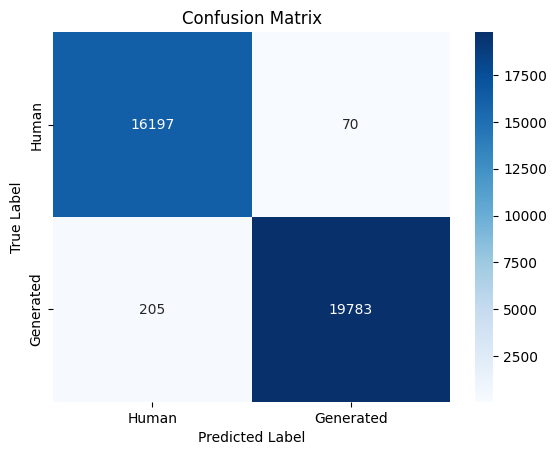

In [8]:
best_model = calculate(X_train, y_train, X_test, y_test)

## Shuffled labels

Перемешаем метки для train, чтобы убедиться в отсутствии утечек. Метрики должны упасть до случайных (~0.50)


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------


/opt/anaconda3/envs/m2gpu/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch time (s)            : 11902.78
Best CV accuracy               : 0.4979
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 1, 'tfidf__max_features': 35000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        35000 10         1       0.4979
        25000 10         1       0.4978
        25000 10         0       0.4848
        35000 10         0       0.4842
        25000  1         0       0.4228

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
life life market access culture employees following recommendations contacted clients needs increasing demand various cultural america caribbean department organization big problem company production yoon shown table environment important strategy increase al 1995 managers ensure factors leading 

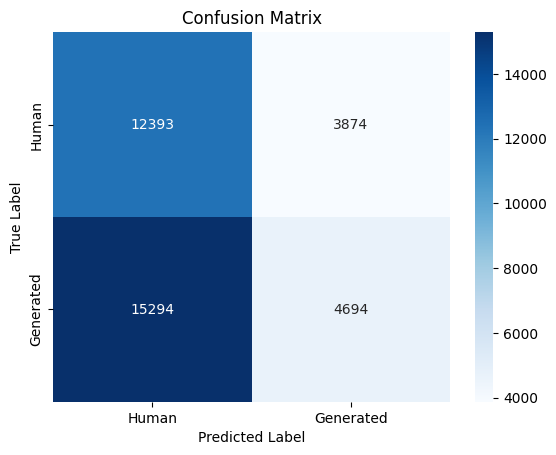

In [9]:
y_train_shuffled = np.random.permutation(y_train)
_ = calculate(X_train, y_train_shuffled, X_test, y_test)

## Примеры текстов

In [10]:
def explain_prediction(text, model):
    vectorizer = model.named_steps['tfidf']
    clf = model.named_steps['clf']

    X_vec = vectorizer.transform([text])

    coef = clf.coef_[0]

    contribution = X_vec.toarray()[0] * coef
    feature_names = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        'word': feature_names,
        'tfidf': X_vec.toarray()[0],
        'coef': coef,
        'contribution': contribution
    })

    df = df[df.tfidf > 0].sort_values('contribution', ascending=False)

    print(f"Предсказанный класс: {model.predict([text])[0]}")
    print("\nСлова, показывающие, что текст СИНТЕТИЧЕСКИЙ:")
    print(df.head(20)[['word', 'contribution']].to_string(index=False))

    print("\nСлова, показывающие, что текст ЖИВОЙ:")
    print(df.tail(20)[['word', 'contribution']].to_string(index=False))

In [6]:
text = ivy_panda_df['text'].iloc[0]
print(text)

Based on a movie by David lean the book “Pillars of Wisdom” is a reflection of a British soldier, Lawrence of Arabia experiences when he worked with the rebel forces as a liaison officer during the revolt by the Arabs against the Ottoman Turks between 1916 and 1918.

According to the story, just before the World War one, Lawrence as a British official had begun his scholarly work in which he focused on the seven great cities in the Middle East. The consequent event was a break out of wars between the Arabs and the Turks. He then claimed to have spoilt the manuscript containing his work.

The war broke in a location called Wadi Rum also known as the valley of the moon. The location of this place is cut into the granite and sandstorm rock at 60 km south east of Akaba. This wadi is the largest in the city of Jordan with the name originating from an Aromatic meaning “elevated” or “high”. The Arabs continued with their revolt against the Ottoman Turks with the situation worsening and everyw

In [11]:
explain_prediction(text, best_model)

Предсказанный класс: 0

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
       word  contribution
  narrative      0.267967
    central      0.145951
    ongoing      0.138006
significant      0.090083
alternative      0.088640
 challenges      0.079006
    support      0.078883
  prominent      0.078069
   societal      0.077464
   language      0.074849
    seeking      0.073567
   allowing      0.072200
     wisdom      0.072136
 background      0.061146
experiences      0.053729
reinforcing      0.051577
      power      0.046171
   designed      0.043964
   engaging      0.043519
        led      0.043218

Слова, показывающие, что текст ЖИВОЙ:
     word  contribution
     used     -0.089390
    movie     -0.091957
   middle     -0.108279
     east     -0.110364
  britain     -0.117301
situation     -0.120098
according     -0.130118
    story     -0.132073
     arab     -0.146250
    arabs     -0.149899
   arabic     -0.162231
     book     -0.169863
countries     -0.175129
    print

In [7]:
text = test_ai_datasets['text'].iloc[0]
print(text)

Steven Spielberg's 2012 film "Lincoln" received widespread critical acclaim for its masterful portrayal of the 16th American President's efforts to abolish slavery. However, another historical drama released around the same time flew under the radar: Steve McQueen's powerful and unflinching adaptation of Solomon Northup's memoir, "12 Years a Slave". Set against the backdrop of pre-Civil War America, this film tells the harrowing tale of a free African American man who is kidnapped and sold into slavery. But beyond its gruesome subject matter lies a deeply nuanced exploration of identity, agency, and the very fabric of humanity.

At its core, "12 Northup's" narrative is a slow-burning meditation on the dehumanizing effects of slavery. McQueen masterfully crafts an atmosphere of oppressive dread through his use of long takes, close-ups, and a desaturated color palette. The audience is transported to antebellum Louisiana, where the once-respectable Solomon Northup (played by Chiwetel Ejio

In [13]:
explain_prediction(text, best_model)

Предсказанный класс: 1

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
             word  contribution
       ultimately      0.623680
           deeply      0.541987
         powerful      0.445565
      exploration      0.304383
           serves      0.291765
         profound      0.199237
         reminder      0.196933
       historical      0.180478
          nuanced      0.174303
          northup      0.156788
         enslaved      0.144177
        portrayal      0.143331
           offers      0.127052
       conclusion      0.124596
        narrative      0.124126
       commitment      0.123672
             lies      0.123423
        masterful      0.120448
         identity      0.116168
enslaved africans      0.111187

Слова, показывающие, что текст ЖИВОЙ:
     word  contribution
  society     -0.057978
   notion     -0.058124
    story     -0.061178
      man     -0.061672
    human     -0.065761
      use     -0.066745
    means     -0.070694
 humanity     -0.075078
  a